## Importação de Bibliotecas

In [1]:
# Dependências
import sys
#!{sys.executable} -m pip install --disable-pip-version-check -r ../requirements.txt -q
print('Bibliotecas instaladas')

Bibliotecas instaladas


In [2]:
# Acesso aos módulos do diretório
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Manipulação dos dados 
import pandas as pd
import numpy as np

# Visualização dos dados
import matplotlib.pyplot as plt
import seaborn as sns

# Funções customizadas
from configs.paths import *
from configs.function_basic import *

# Avisos
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Configuração
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', None)

print('✅ Bibliotecas carregadas com sucesso')

Diretórios carregados com sucesso
Funções básicas carregadas com sucesso
✅ Bibliotecas carregadas com sucesso


## Carregamento dos Dados

In [3]:
# Carregar dados
abt00 = pd.read_parquet(RAW_DIR / 'base_tabelao.parquet')

print(f'✅ Dados carregados')

✅ Dados carregados


## Análise Inicial dos Dados

In [4]:
# Informações básicas
print('imformações básicas'.upper())
print('=' * 30)

basic_information(abt00)

IMFORMAÇÕES BÁSICAS
Dataset carregado com 1,272,095 registros e 108 colunas
Colunas: ['SAFRA', 'FLAG_INSTALACAO', 'FPD_bureau', 'PROD', 'flag_mig2_bureau', 'SCORE_01', 'SCORE_02', 'NUM_CPF', 'FPD_telco', 'flag_mig2_telco', 'var_26', 'var_27', 'var_28', 'var_29', 'var_30', 'var_31', 'var_32', 'var_33', 'var_34', 'var_35', 'var_36', 'var_37', 'var_38', 'var_39', 'var_40', 'var_41', 'var_42', 'var_43', 'var_44', 'var_45', 'var_46', 'var_47', 'var_48', 'var_49', 'var_50', 'var_51', 'var_52', 'var_53', 'var_54', 'var_55', 'var_56', 'var_57', 'var_58', 'var_59', 'var_60', 'var_61', 'var_62', 'var_63', 'var_64', 'var_65', 'var_66', 'var_67', 'var_68', 'var_69', 'var_70', 'var_71', 'var_72', 'var_73', 'var_74', 'var_75', 'var_76', 'var_77', 'var_78', 'var_79', 'var_80', 'var_81', 'var_82', 'var_83', 'var_84', 'var_85', 'var_86', 'var_87', 'var_88', 'var_89', 'var_90', 'var_91', 'var_92', 'var_93', 'FLAG_INSTALACAO_cadastrais', 'FPD', 'flag_mig2', 'STATUSRF', 'DATADENASCIMENTO', 'var_03', 'var_

In [5]:
# Informações dos tipos de dados
print('tipo dos dados'.upper())
print('=' * 30)

data_type(abt00)

TIPO DOS DADOS
float64        : 94 variáveis
object         : 9 variáveis
Int64          : 3 variáveis
int32          : 2 variáveis

📊 Total: 108 variáveis

 DETALHAMENTO POR VARIÁVEL:
SAFRA                          → 📝 Texto/Categórica
FLAG_INSTALACAO                → 🔢 Número Inteiro
FPD_bureau                     → 🔢 Número Inteiro
PROD                           → 📝 Texto/Categórica
flag_mig2_bureau               → 📝 Texto/Categórica
SCORE_01                       → 🔢 Número Decimal
SCORE_02                       → 🔢 Número Decimal
NUM_CPF                        → 📝 Texto/Categórica
FPD_telco                      → 🔢 Número Inteiro
flag_mig2_telco                → 📝 Texto/Categórica
var_26                         → 🔢 Número Decimal
var_27                         → 🔢 Número Decimal
var_28                         → 🔢 Número Decimal
var_29                         → 🔢 Número Decimal
var_30                         → 🔢 Número Decimal
var_31                         → 🔢 Número Decimal
var_3

 Ajuste de Tipos de Dados

Para garantir consistência analítica e evitar problemas ao longo do pipeline, será necessário ajustar o tipo de dados de algumas colunas:

- **DATADENASCIMENTO**: conversão para o tipo `datetime`, permitindo operações temporais, validações e cálculos de idade.
- **CEP_3_digitos**: conversão para o tipo `int`, assegurando padronização e melhor desempenho em agregações e análises numéricas.

Esse ajuste reduz risco operacional e aumenta a robustez do dataset para etapas posteriores.

In [6]:
# Visualizando os dados 
print('Visualizando os dados'.upper())
print('=' * 30)
show_dataframe_samples(abt00)

VISUALIZANDO OS DADOS

 PRIMEIRAS 3 LINHAS:


,SAFRA,FLAG_INSTALACAO,FPD_bureau,PROD,flag_mig2_bureau,SCORE_01,SCORE_02,NUM_CPF,FPD_telco,flag_mig2_telco,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,var_34,var_35,var_36,var_37,var_38,var_39,var_40,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49,var_50,var_51,var_52,var_53,var_54,var_55,var_56,var_57,var_58,var_59,var_60,var_61,var_62,var_63,var_64,var_65,var_66,var_67,var_68,var_69,var_70,var_71,var_72,var_73,var_74,var_75,var_76,var_77,var_78,var_79,var_80,var_81,var_82,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93,FLAG_INSTALACAO_cadastrais,FPD,flag_mig2,STATUSRF,DATADENASCIMENTO,var_03,var_02,var_04,var_05,var_06,var_07,var_08,var_09,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20,var_21,var_22,var_23,var_24,var_25,CEP_3_digitos
0,202410,1,0,CMV,PRE,562.0,636.0,ZZZZZX7XWY8,0,PRE,1.0,1.0,71.43,24.49,72.43,93.62,51.45,45.54,27.4,23.01,304.00,304.0,304.00,304.00,27.78,61.91,87.64,68.58,25.92,76.16,46.21,100.00,20.38,100.0,4.44,0.0,0.0,11.92,49.85,87.98,99.59,100.0,100.0,33.33,0.65,90.91,94.93,76.07,98.14,0.0,37.99,96.40,96.95,48.90,100.0,304.0,100.0,0.0,304.0,304.0,304.0,0.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,2.0,3.0,1.0,50.0,0.86,2.0,1.0,1.0,1,0,PRE,REGULAR,26/12/1983,33.0,NaN,0.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,479
1,202410,1,1,CMV,PRE,546.0,518.0,ZZZZZX88YXY,1,PRE,1.0,0.0,78.25,24.49,0.00,100.00,0.00,0.00,304.0,304.00,304.00,304.0,304.00,304.00,0.19,1.05,5.99,5.99,0.24,76.16,35.84,90.91,94.56,100.0,91.67,0.0,0.0,0.09,48.64,24.49,100.00,100.0,100.0,100.00,4.66,0.00,2.50,0.00,0.00,0.0,9.97,46.21,0.00,53.79,100.0,304.0,304.0,0.0,304.0,304.0,304.0,0.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.00,304.0,304.0,304.0,1,1,PRE,REGULAR,24/12/1980,14.0,NaN,0.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,690
2,202410,1,0,CMV,PRE,621.0,750.0,ZZZZZYT7XYT,0,PRE,1.0,1.0,75.75,80.93,95.02,0.00,100.00,99.99,100.0,99.96,6.19,66.4,73.59,35.97,99.96,100.00,81.44,76.16,77.83,76.16,46.21,100.00,96.56,100.0,11.58,0.0,0.0,1.80,0.00,55.46,100.00,100.0,100.0,39.83,100.00,85.37,99.77,60.00,58.28,0.0,83.37,95.02,70.12,52.53,100.0,100.0,100.0,0.0,304.0,304.0,304.0,0.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,0.0,1.0,1.0,100.0,298.00,1.0,1.0,2.0,1,0,PRE,REGULAR,23/07/1982,33.0,NaN,0.0,4.0,NaN,NaN,NaN,NaN,NaN,3282.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,790



 ÚLTIMAS 3 LINHAS:


,SAFRA,FLAG_INSTALACAO,FPD_bureau,PROD,flag_mig2_bureau,SCORE_01,SCORE_02,NUM_CPF,FPD_telco,flag_mig2_telco,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,var_34,var_35,var_36,var_37,var_38,var_39,var_40,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49,var_50,var_51,var_52,var_53,var_54,var_55,var_56,var_57,var_58,var_59,var_60,var_61,var_62,var_63,var_64,var_65,var_66,var_67,var_68,var_69,var_70,var_71,var_72,var_73,var_74,var_75,var_76,var_77,var_78,var_79,var_80,var_81,var_82,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93,FLAG_INSTALACAO_cadastrais,FPD,flag_mig2,STATUSRF,DATADENASCIMENTO,var_03,var_02,var_04,var_05,var_06,var_07,var_08,var_09,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20,var_21,var_22,var_23,var_24,var_25,CEP_3_digitos
1272092,202503,1,0,CMV,PRE,616.0,630.0,9999888YYU9,0,PRE,1.0,1.0,19.00,304.0,0.0,4.19,20.96,23.21,25.99,27.75,304.0,304.0,304.0,304.0,5.31,17.17,304.00,304.00,304.00,76.16,35.84,100.0,72.43,100.00,10.00,96.95,50.20,11.92,27.74,63.51,73.98,100.0,100.0,16.67,19.69,75.0,24.49,62.29,32.15,0.0,9.97,46.21,0.00,53.79,8.33,304.0,100.0,1000.0,304.0,304.0,304.0,0.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,4.0,3.0,6.0,0.0,1.56,6.0,4.0,0.0,1,0,PRE,REGULAR,26/12/1988,29.0,NaN,0.0,3.0,NaN,NaN,NaN,9.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,769
1272093,202503,1,0,CMV,PRE,627.0,649.0,9999889ZN9X,0,PRE,1.0,0.0,26.13,304.0,0.0,23.69,11.58,15.67,304.00,304.00,304.0,304.0,304.0,304.0,5.81,22.78,304.00,304.00,304.00,76.16,35.84,0.0,6.66,72.73,8.33,96.95,63.52,73.11,53.99,35.84,92.89,100.0,100.0,40.83,31.60,0.0,0.00,0.00,0.00,0.0,9.97,39.41,100.00,57.44,91.67,304.0,304.0,1000.0,304.0,304.0,304.0,0.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,3.0,2.0,1.0,0.0,1.16,5.0,1.0,0.0,1,0,PRE,REGULAR,15/09/1963,NaN,715405.0,0.0,2.0,NaN,NaN,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN,440.0,202406.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,339
1272094,202503,1,1,CMV,PRE,577.0,611.0,999998YZYNW,1,PRE,1.0,0.0,304.00,304.0,304.0,100.00,0.00,0.00,304.00,304.00,304.0,304.0,304.0,304.0,0.00,0.00,90.51,86.17,3.47,0.00,0.00,304.0,0.00,304.00,0.00,304.00,304.00,50.00,50.00,0.00,0.00,0.0,304.0,304.00,304.00,304.0,304.00,304.00,93.11,0.0,90.51,96.40,27.26,49.65,100.00,100.0,304.0,0.0,304.0,304.0,304.0,0.0,304.0,304.0,6.0,304.0,304.0,304.0,304.0,1.0,304.0,304.0,304.0,304.0,304.00,304.0,304.0,304.0,1,1,PRE,REGULAR,21/01/1987,19.0,725505.0,0.0,2.0,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,768



 AMOSTRA ALEATÓRIA:


,SAFRA,FLAG_INSTALACAO,FPD_bureau,PROD,flag_mig2_bureau,SCORE_01,SCORE_02,NUM_CPF,FPD_telco,flag_mig2_telco,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,var_34,var_35,var_36,var_37,var_38,var_39,var_40,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49,var_50,var_51,var_52,var_53,var_54,var_55,var_56,var_57,var_58,var_59,var_60,var_61,var_62,var_63,var_64,var_65,var_66,var_67,var_68,var_69,var_70,var_71,var_72,var_73,var_74,var_75,var_76,var_77,var_78,var_79,var_80,var_81,var_82,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93,FLAG_INSTALACAO_cadastrais,FPD,flag_mig2,STATUSRF,DATADENASCIMENTO,var_03,var_02,var_04,var_05,var_06,var_07,var_08,var_09,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20,var_21,var_22,var_23,var_24,var_25,CEP_3_digitos
685057,202501,1,1,CMV,PRE,574.0,544.0,ZY9TZNWXT7N,1,PRE,1.0,0.0,304.0,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.0,304.0,304.0,304.0,304.00,304.00,304.0,304.0,304.00,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.00,304.0,304.0,304.0,304.0,304.0,304.00,304.00,304.00,304.0,304.00,304.00,304.00,304.00,304.0,304.0,304.0,0.0,304.0,304.0,304.0,0.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.00,304.0,304.0,304.0,1,1,PRE,REGULAR,21/05/1985,42.0,NaN,0.0,2.0,1.0,1963.3,31.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115
81582,202410,1,1,CMV,PRE,555.0,625.0,Z99887WY8U8,1,PRE,1.0,1.0,0.0,35.84,16.51,0.05,25.39,19.00,25.23,18.21,304.0,304.0,304.0,304.0,15.52,32.76,4.0,4.0,1.07,0.0,0.0,304.0,0.0,304.0,0.0,304.0,304.0,50.0,50.0,0.0,0.00,0.0,304.0,304.0,304.0,100.0,64.98,85.22,0.00,0.0,19.74,46.21,0.00,53.79,100.0,304.0,100.0,1000.0,304.0,304.0,304.0,0.0,304.0,304.0,1.0,304.0,304.0,304.0,304.0,1.0,1.0,5.0,6.0,17.0,0.94,3.0,3.0,1.0,1,1,PRE,REGULAR,16/07/1966,34.0,NaN,4.0,1.0,NaN,NaN,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN,440.0,202311.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,009
47344,202410,1,0,CMV,PRE,617.0,590.0,ZTZ8TU99U9Y,0,PRE,1.0,1.0,0.0,304.00,39.41,20.14,68.69,47.75,78.28,55.56,304.0,304.0,304.0,304.0,39.78,64.26,304.0,304.0,304.00,0.0,0.0,304.0,0.0,304.0,0.0,304.0,304.0,50.0,50.0,0.0,33.64,0.0,304.0,304.0,304.0,100.0,53.70,76.16,32.15,0.0,29.13,72.43,99.99,43.03,304.0,304.0,100.0,0.0,304.0,304.0,304.0,0.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,3.0,4.0,1.0,35.0,0.87,6.0,1.0,1.0,1,0,PRE,REGULAR,13/08/1979,51.0,NaN,0.0,1.0,NaN,NaN,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN,600.0,202311.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,559


### Visão Geral do Dataset

O dataset representa uma base de clientes associada a uma **safra específica**, consolidando informações cadastrais, comportamentais, scores externos e variáveis derivadas para análise de risco e performance.

### Estrutura das Variáveis

- **Identificação e Safra**
  - `SAFRA`: referência temporal do dataset (formato AAAAMM).
  - `NUM_CPF`: identificador único do cliente (anonimizado).

- **Produto e Status**
  - `PROD`: tipo de produto contratado.
  - `STATUSRF`: status regulatório do cliente.
  - `FLAG_INSTALACAO`, `FLAG_INSTALACAO_cadastrais`: indicadores de instalação do serviço.

- **Indicadores de Risco e Performance**
  - `FPD`, `FPD_bureau`, `FPD_telco`: flags de First Payment Default por origem.
  - `flag_mig2`, `flag_mig2_bureau`, `flag_mig2_telco`: indicadores de migração de risco.
  - `SCORE_01`, `SCORE_02`: scores preditivos utilizados no processo decisório.

- **Variáveis Derivadas**
  - `var_02` a `var_93`: conjunto de variáveis numéricas derivadas, utilizadas para modelagem estatística e machine learning.  
    Incluem métricas normalizadas, percentuais, contagens e indicadores comportamentais.

- **Dados Cadastrais**
  - `DATADENASCIMENTO`: data de nascimento do cliente.
  - `CEP_3_digitos`: agregação geográfica do CEP (3 primeiros dígitos).

### Observações Importantes

- O dataset apresenta **valores nulos** em algumas variáveis derivadas, exigindo tratamento prévio.
- Existem variáveis com **alta repetição de valores constantes**, possivelmente flags ou indicadores técnicos.
- Recomenda-se validação de tipos (`datetime`, `int`, `float`) antes de qualquer etapa de modelagem.
- A granularidade das variáveis sugere uso principal em **modelos de crédito / risco**.

## Análise da Variável Target (FPD)


📊 ANÁLISE DA VARIÁVEL TARGET: FPD

Distribuição:
   0: 975,013 (76.6%)
   1: 297,082 (23.4%)


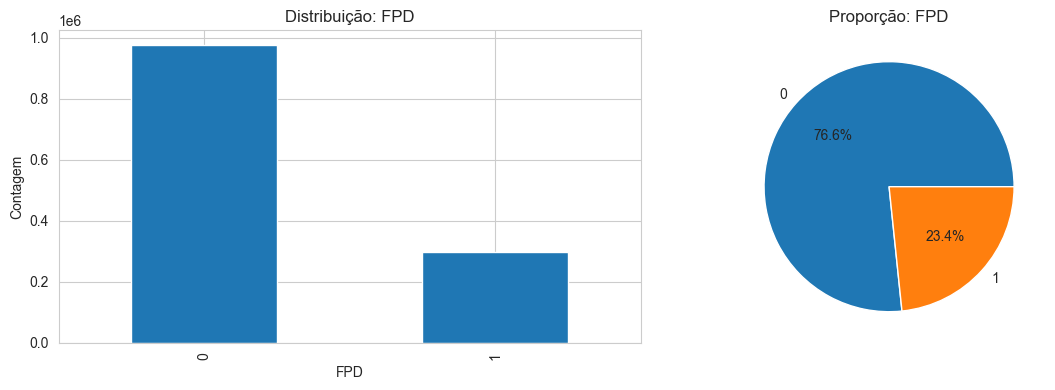

In [7]:
# Análise do target
analyze_target(abt00, target_col='FPD')

In [8]:
# Estatísticas do target
total = len(abt00)
bons = (abt00['FPD'] == 0).sum()
maus = (abt00['FPD'] == 1).sum()

print(f'\n📊 DISTRIBUIÇÃO DO TARGET (FPD):')
print(f'   Total de registros: {total:,}')
print(f'   Bons pagadores (0): {bons:,} ({bons/total*100:.2f}%)')
print(f'   Maus pagadores (1): {maus:,} ({maus/total*100:.2f}%)')
print(f'   Taxa de inadimplência: {maus/total*100:.2f}%')

# Verificar balanceamento
ratio = bons / maus
print(f'\n⚖️ Desbalanceamento: {ratio:.2f}:1 (bons:maus)')
if ratio > 2:
    print('   ⚠️ Dataset desbalanceado - considerar técnicas de balanceamento')


📊 DISTRIBUIÇÃO DO TARGET (FPD):
   Total de registros: 1,272,095
   Bons pagadores (0): 975,013 (76.65%)
   Maus pagadores (1): 297,082 (23.35%)
   Taxa de inadimplência: 23.35%

⚖️ Desbalanceamento: 3.28:1 (bons:maus)
   ⚠️ Dataset desbalanceado - considerar técnicas de balanceamento


## Análise de Valores Faltantes


⚠️ Missing values in 81 variables:

var_12                         → 1,272,095 (100.0%)
var_25                         → 1,272,095 (100.0%)
var_24                         → 1,272,095 (100.0%)
var_23                         → 1,272,095 (100.0%)
var_22                         → 1,272,095 (100.0%)
var_21                         → 1,272,095 (100.0%)
var_20                         → 1,272,095 (100.0%)
var_19                         → 1,272,095 (100.0%)
var_18                         → 1,272,095 (100.0%)
var_15                         → 1,272,095 (100.0%)
var_10                         → 1,271,717 (100.0%)
var_11                         → 1,258,855 (99.0%)
var_13                         → 1,223,348 (96.2%)
var_02                         → 1,201,123 (94.4%)
var_14                         → 1,174,885 (92.4%)
var_07                         → 1,059,724 (83.3%)
var_17                         → 1,049,094 (82.5%)
var_16                         → 1,049,094 (82.5%)
var_08                         → 1

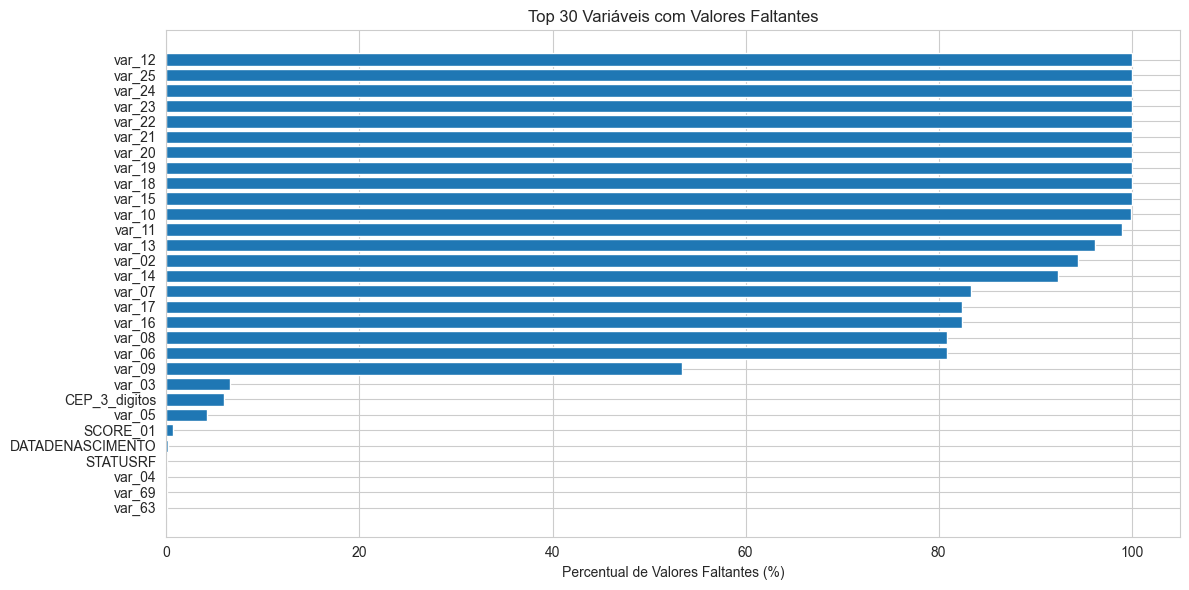

In [9]:
# Análise de missing values
missing_df = analyze_missing_values(abt00, plot=False)

# Visualizar top 30 variáveis com missing
if not missing_df.empty:
    top_missing = missing_df.head(30)
    
    plt.figure(figsize=(12, 6))
    plt.barh(range(len(top_missing)), top_missing['Percentage'])
    plt.yticks(range(len(top_missing)), top_missing['Variable'])
    plt.xlabel('Percentual de Valores Faltantes (%)')
    plt.title('Top 30 Variáveis com Valores Faltantes')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## Análise de Duplicatas

In [10]:
# Verificação de duplicatas
print('análise de duplicatas'.upper())
print('=' * 30)

check_duplicates(abt00)

ANÁLISE DE DUPLICATAS
Registros duplicados: 0
✅ Nenhuma duplicata encontrada


## Tabela Resumo do Dataset

In [11]:
# Tabela de informações
info_table = dataset_info_table(abt00)

# Salvar tabela
info_table.to_csv(ARTIFACT_DIR / 'metadata.csv', index=False)
print(f'\n✅ Tabela salva em: {ARTIFACT_DIR / "metadata.csv"}')
display(info_table)


✅ Tabela salva em: C:\Users\billy.reis\Desktop\hackathon_pod\hackathon\artifact\metadata.csv


,variavel,tipo,n_nulos,Nulos_%,cardinalidade
0,SAFRA,categorica,0,0.00,6
1,FLAG_INSTALACAO,numerica,0,0.00,1
2,FPD_bureau,numerica,0,0.00,2
3,PROD,categorica,0,0.00,1
4,flag_mig2_bureau,categorica,0,0.00,1
...,...,...,...,...,...
103,var_22,numerica,1272095,100.00,0
104,var_23,numerica,1272095,100.00,0
105,var_24,numerica,1272095,100.00,0
106,var_25,numerica,1272095,100.00,0


## Análise de Variáveis Numéricas

In [12]:
# Selecionar variáveis numéricas (exceto target)
numerical_cols = abt00.select_dtypes(include=[np.number]).columns.tolist()

for col in ['FPD', 'FPD_bureau', 'FPD_telco']:
    if col in numerical_cols:
        numerical_cols.remove(col)

print(f'\n📊 Total de variáveis numéricas: {len(numerical_cols)}')
print(f'\nExemplos: {numerical_cols[:10]}')


📊 Total de variáveis numéricas: 96

Exemplos: ['FLAG_INSTALACAO', 'SCORE_01', 'SCORE_02', 'var_26', 'var_27', 'var_28', 'var_29', 'var_30', 'var_31', 'var_32']


In [14]:
# estatísticas descritivas das principais features numéricas
main_vars = ['SCORE_01', 'SCORE_02']

existing_vars = [v for v in main_vars if v in abt00.columns]

if existing_vars:
    print('\n📊 ESTATÍSTICAS DESCRITIVAS - FEATURES PRINCIPAIS:')
    display(abt00[['SCORE_01', 'SCORE_02']].describe().style.format('{:.2f}'))


📊 ESTATÍSTICAS DESCRITIVAS - FEATURES PRINCIPAIS:


,SCORE_01,SCORE_02
count,1262731.00,1271583.00
mean,587.04,628.03
std,57.53,96.01
min,0.00,1.00
25%,554.00,558.00
50%,587.00,623.00
75%,621.00,697.00
max,778.00,917.00


Os scores apresentam comportamentos distintos. O SCORE_02 possui média mais elevada e maior dispersão, indicando maior poder de discriminação entre perfis de risco. Já o SCORE_01 é mais concentrado, sugerindo uma régua mais conservadora e estável. A presença de valores mínimos iguais a zero no SCORE_01 indica a necessidade de validação de regra ou tratamento específico.  
SCORE_02 separa melhor, SCORE_01 dá estabilidade.


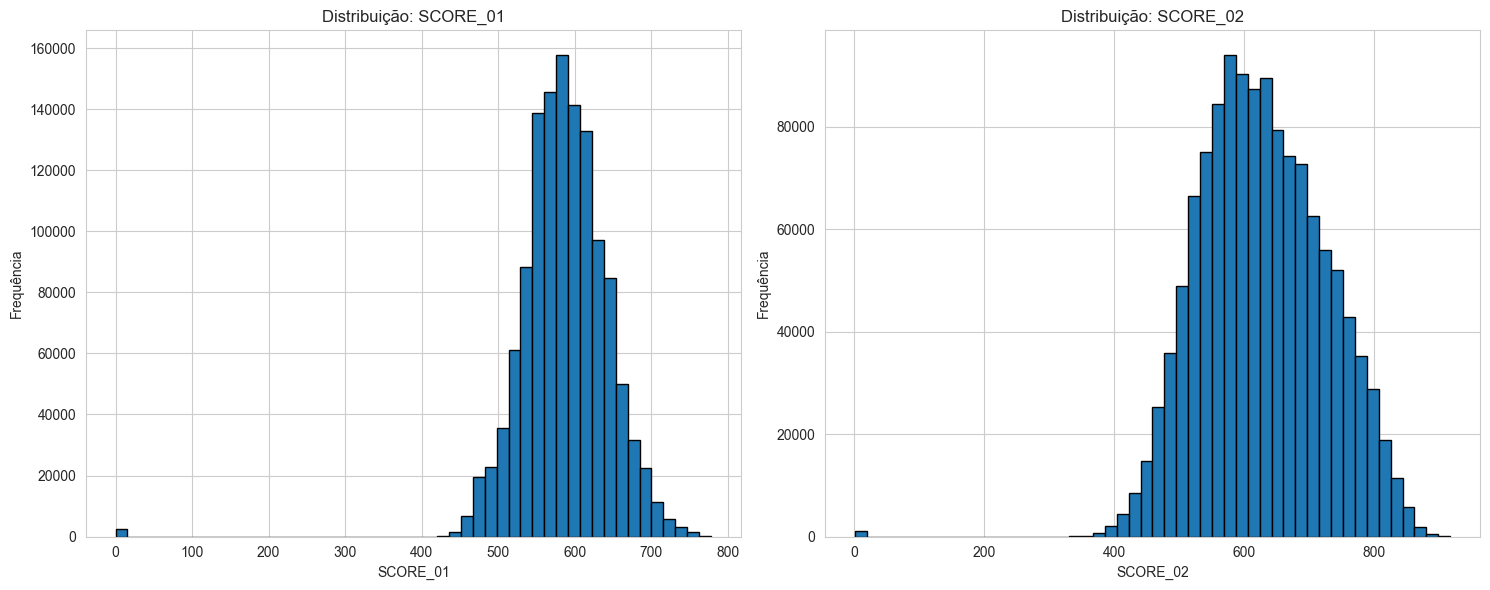

In [18]:
# Distribuições das principais variáveis numéricas
if existing_vars:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    axes = axes.flatten()
    
    for i, var in enumerate(existing_vars):
        if i < 4:
            abt00[var].hist(bins=50, ax=axes[i], edgecolor='black')
            axes[i].set_title(f'Distribuição: {var}')
            axes[i].set_xlabel(var)
            axes[i].set_ylabel('Frequência')
    
    plt.tight_layout()
    plt.show()

## Análise de Variáveis Categóricas

In [19]:
# Análise de variáveis categóricas
categorical_cols = abt00.select_dtypes(include=['object']).columns.tolist()

print(f'\n📊 Total de variáveis categóricas: {len(categorical_cols)}')
print(f'\nVariáveis: {categorical_cols}')


📊 Total de variáveis categóricas: 9

Variáveis: ['SAFRA', 'PROD', 'flag_mig2_bureau', 'NUM_CPF', 'flag_mig2_telco', 'flag_mig2', 'STATUSRF', 'DATADENASCIMENTO', 'CEP_3_digitos']


In [20]:
# Analisar principais categóricas
if categorical_cols:
    analyze_categorical_features(abt00[categorical_cols], max_unique=20)


🏷️ SAFRA:
   Valores únicos: 6
   Valores e frequências:
      202411: 226,119 (17.8%)
      202412: 225,760 (17.7%)
      202501: 217,590 (17.1%)
      202410: 203,828 (16.0%)
      202503: 200,729 (15.8%)
      202502: 198,069 (15.6%)

🏷️ PROD:
   Valores únicos: 1
   Valores e frequências:
      CMV: 1,272,095 (100.0%)

🏷️ FLAG_MIG2_BUREAU:
   Valores únicos: 1
   Valores e frequências:
      PRE: 1,272,095 (100.0%)

🏷️ NUM_CPF:
   Valores únicos: 1,272,095
   ⚠️ Muitos valores únicos (1,272,095) - variável de alta cardinalidade

🏷️ FLAG_MIG2_TELCO:
   Valores únicos: 1
   Valores e frequências:
      PRE: 1,272,095 (100.0%)

🏷️ FLAG_MIG2:
   Valores únicos: 1
   Valores e frequências:
      PRE: 1,272,095 (100.0%)

🏷️ STATUSRF:
   Valores únicos: 5
   Valores e frequências:
      REGULAR: 1,263,235 (99.3%)
      PENDENTE DE REGULARIZACAO: 7,151 (0.6%)
      SUSPENSA: 210 (0.0%)
      TITULAR FALECIDO: 66 (0.0%)
      CANCELADA: 4 (0.0%)

🏷️ DATADENASCIMENTO:
   Valores únicos: 26,

## Correlação com o Target

In [26]:
# calcula correlação real das variáveis com o target FPD
correlations = (abt00[numerical_cols + ['FPD']].corr()['FPD'].drop('FPD').sort_values(ascending=False))

In [27]:
# separa correlações positivas e negativas
corr_pos = correlations[correlations > 0]
corr_neg = correlations[correlations < 0]

In [28]:
print('\n📈 TOP 10 CORRELAÇÕES POSITIVAS COM FPD:')
print(corr_pos.head(10))

print('\n📉 TOP 10 CORRELAÇÕES NEGATIVAS COM FPD:')
print(corr_neg.tail(10))


📈 TOP 10 CORRELAÇÕES POSITIVAS COM FPD:
var_28    0.098942
var_31    0.087327
var_30    0.076950
var_02    0.075712
var_50    0.074474
var_48    0.073688
var_45    0.073120
var_34    0.072637
var_46    0.067340
var_57    0.066733
Name: FPD, dtype: float64

📉 TOP 10 CORRELAÇÕES NEGATIVAS COM FPD:
var_13     -0.008195
var_47     -0.018365
var_52     -0.025155
var_51     -0.025367
var_11     -0.030850
var_04     -0.046527
var_05     -0.090674
var_73     -0.095242
SCORE_01   -0.215114
SCORE_02   -0.288953
Name: FPD, dtype: float64


A análise de correlação evidencia dois comportamentos distintos. As variáveis com correlação positiva apresentam impacto incremental sobre o risco de FPD,  
enquanto os scores possuem correlação negativa mais intensa, indicando efeito protetivo consistente. Esse resultado reforça o papel central dos scores na modelagem, com as demais variáveis atuando como complementares no processo decisório.


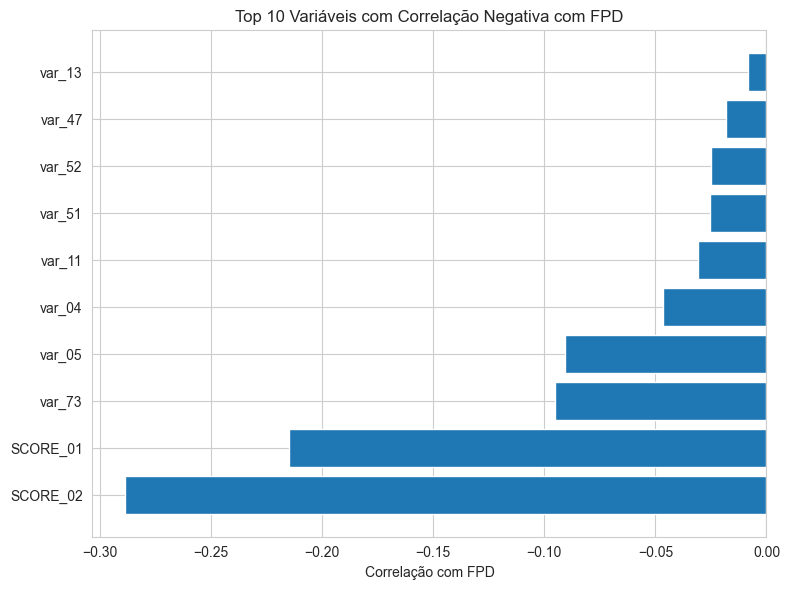

In [29]:
# plota top correlações negativas
top_neg = corr_neg.sort_values().head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_neg.index, top_neg.values)
plt.xlabel('Correlação com FPD')
plt.title('Top 10 Variáveis com Correlação Negativa com FPD')
plt.axvline(x=0, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### Correlação das Variáveis com o FPD

As variáveis com maior correlação absoluta com o target **FPD** apresentam, em sua maioria, **associações fracas a moderadas**, com destaque para os scores externos.

- **SCORE_02 (ρ ≈ 0,29)** e **SCORE_01 (ρ ≈ 0,21)** são as variáveis mais informativas, reforçando seu papel como principais indicadores de risco.
- As demais variáveis (`var_XX`) possuem correlações individuais inferiores a 0,10, sugerindo **baixo poder explicativo isolado**.
- A ausência de correlações elevadas indica que o risco não é explicado por uma única variável, mas sim pela **combinação de múltiplos sinais**.

### Implicações Analíticas

- Scores devem ser tratados como **features-chave** no processo de modelagem.
- Variáveis derivadas contribuem de forma incremental e tendem a performar melhor em **modelos multivariados**.
- Não há evidência de vazamento de informação, dado que nenhuma variável apresenta correlação excessivamente alta com o target.

Esse cenário reforça a necessidade de uso de **modelos estatísticos ou de machine learning**, em vez de regras univariadas.


## Análise por SAFRA


📊 ANÁLISE POR SAFRA:


,Total,Taxa_Inadimplencia,Total_Inadimplentes
SAFRA,,,
202410,203828,0.2269,46239
202411,226119,0.2483,56138
202412,225760,0.2379,53709
202501,217590,0.2338,50876
202502,198069,0.2198,43528
202503,200729,0.2321,46592


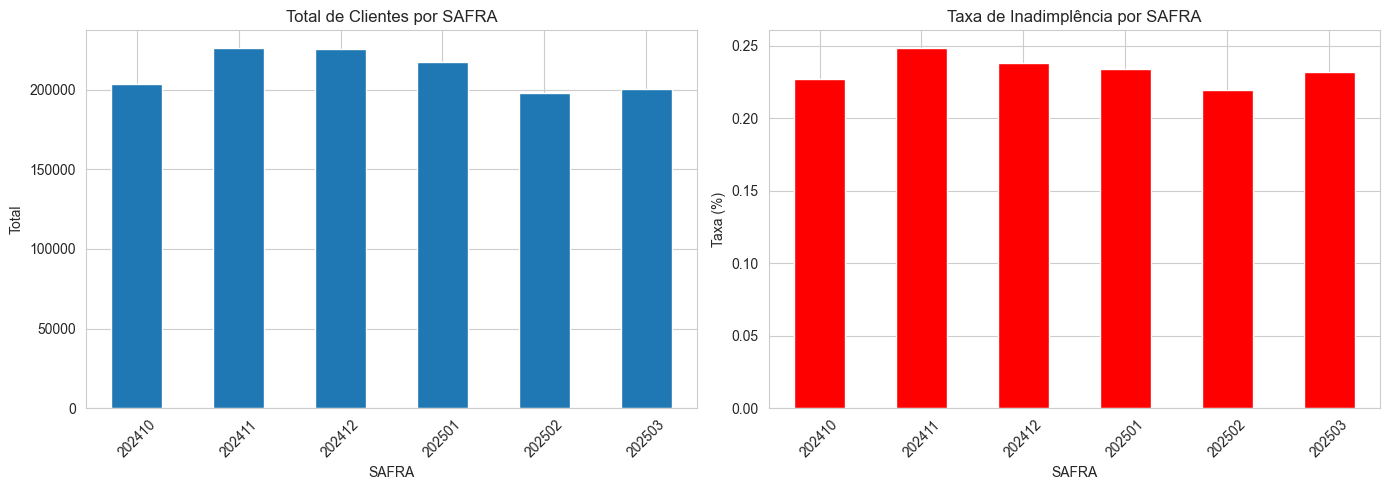

In [30]:
# Análise temporal por SAFRA
if 'SAFRA' in abt00.columns:
    print('\n📊 ANÁLISE POR SAFRA:')
    safra_analysis = abt00.groupby('SAFRA').agg({
        'FPD': ['count', 'mean', 'sum']
    }).round(4)
    safra_analysis.columns = ['Total', 'Taxa_Inadimplencia', 'Total_Inadimplentes']
    display(safra_analysis)
    
    # Visualização
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Total por safra
    safra_analysis['Total'].plot(kind='bar', ax=axes[0])
    axes[0].set_title('Total de Clientes por SAFRA')
    axes[0].set_xlabel('SAFRA')
    axes[0].set_ylabel('Total')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Taxa de inadimplência por safra
    safra_analysis['Taxa_Inadimplencia'].plot(kind='bar', ax=axes[1], color='red')
    axes[1].set_title('Taxa de Inadimplência por SAFRA')
    axes[1].set_xlabel('SAFRA')
    axes[1].set_ylabel('Taxa (%)')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

A análise por safra indica estabilidade no volume de clientes, com variação controlada ao longo do período. Observa-se um pico de inadimplência em 202411, seguido por redução gradual nas safras posteriores, sugerindo ajuste ou amadurecimento da política de concessão. O leve aumento em 202503 merece monitoramento, mas permanece abaixo do pior cenário observado.  
Cresceu rápido em 202411 e pagou o preço.  
Depois apertou o freio e a inadimplência respondeu.

## 12. Conclusões do Entendimento dos Dados

### Principais Conclusões

- **Volume e Complexidade:**  
  O dataset possui 1.272.095 registros e 108 variáveis, caracterizando uma base robusta e adequada para modelagem preditiva de risco.

- **Variável Target (FPD):**  
  A taxa de inadimplência é de aproximadamente 23,4%, com leve desbalanceamento da base (≈3,3:1). Esse cenário é adequado para modelagem, exigindo apenas atenção na escolha das métricas de avaliação.

- **Qualidade dos Dados:**  
  Observa-se presença relevante de valores faltantes em diversas variáveis, o que demanda estratégias de tratamento e imputação antes da modelagem.

- **Sinais Relevantes de Risco:**  
  Os scores de crédito (**SCORE_01** e **SCORE_02**) concentram o maior poder discriminatório individual, enquanto as demais variáveis atuam de forma complementar, reforçando a necessidade de abordagem multivariada.

- **Implicações Analíticas:**  
  Não há evidência de uma variável isolada capaz de explicar o FPD, o que reforça o uso de modelos estatísticos ou de machine learning em detrimento de regras univariadas.

- **Próximos Passos:**  
  - Tratamento de valores ausentes  
  - Feature engineering e seleção de variáveis  
  - Avaliação de métricas de separação (KS, Gini)  
  - Construção e validação de modelos preditivos
